# GSVD alignment angle on CIFAR-10

End-to-end demo of **gsvdlib** on a dataset that is *not* MNIST: natural
images from CIFAR-10 (32×32, converted to grayscale → vectors in ℝ¹⁰²⁴).

We build **A** from one class and **B** from another, compute the blocked
GSVD `A = U·C·H`, `B = Ṽ·S·H`, inspect the block structure and the shared
directions, and classify test images by the alignment angle θ(z).

Pair used here: **Airplane vs Ship** — both share a lot of "blue background"
structure, so the shared block (and θ) is interesting. At the end we repeat
the metrics for **Cat vs Dog** (a much harder pair).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from gsvdlib import (CIFAR10Dataset, prepare_data, evaluate_pair,
                     theta_angles, metrics_from_angles, linear_cka,
                     get_angles_C, highlight_closest)
from gsvdlib.plots import (ImageRenderer, plot_samples, plot_recon,
                           plot_angles, plot_angle_histogram, plot_posterior)

ds = CIFAR10Dataset()          # downloads once to ~/.gsvdlib/cifar10
render = ImageRenderer(shape=(32, 32), cmap="gray")

LABEL_A, LABEL_B = 0, 8        # Airplane, Ship
print(ds.class_name(LABEL_A), "vs", ds.class_name(LABEL_B))

Airplane vs Ship


## 1. Build A and B and look at the samples

`prepare_data` samples the two classes, centers each one (removing its mean
image) and computes `gsvd(A.T, B.T).sorted()` — the co-span formulation used
in the paper, with the shared block sorted so angles increase 0° → 90°.

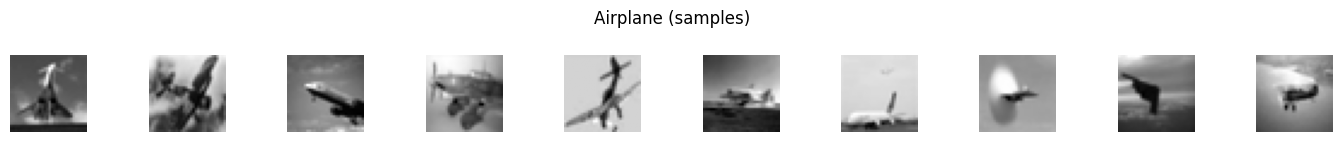

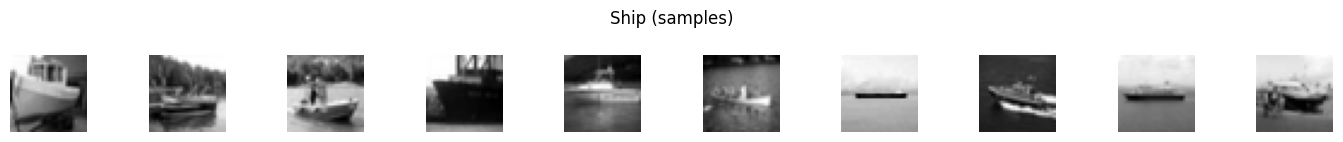

In [2]:
prep = prepare_data(ds, LABEL_A, LABEL_B, n_A=900, n_B=800, seed=1234)

plot_samples(prep.A, render, k=10, mean=prep.mean_A,
             title=f"{ds.class_name(LABEL_A)} (samples)");
plot_samples(prep.B, render, k=10, mean=prep.mean_B,
             title=f"{ds.class_name(LABEL_B)} (samples)");

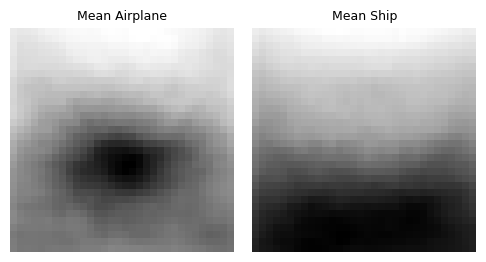

In [3]:
# the two class means ("average airplane" / "average ship")
fig, axes = plt.subplots(1, 2, figsize=(5, 2.6))
render(axes[0], prep.mean_A, title=f"Mean {ds.class_name(LABEL_A)}")
render(axes[1], prep.mean_B, title=f"Mean {ds.class_name(LABEL_B)}")
plt.tight_layout()

## 2. The GSVD and its block structure

In [4]:
g = prep.gsvd   # GSVDResult, already sorted

print("U:", g.U.shape, " V_til:", g.V_til.shape, " H:", g.H.shape)
print("C:", g.C.shape, " S:", g.S.shape,
      " C_til/S_til:", g.C_til.shape)
print(f"blocks: bl={g.bl}  br={g.br}  wl={g.wl}  wr={g.wr}  r={g.r}")

# reconstruction check (A and B here are features x samples, GSVD ran on A.T)
errA = np.linalg.norm(prep.A.T - g.U @ g.C @ g.H)
errB = np.linalg.norm(prep.B.T - g.V_til @ g.S @ g.H)
print(f"||A' - U C H|| = {errA:.2e}   ||B' - V_til S H|| = {errB:.2e}")

# CS identity on the shared block
c, s = np.diag(g.C_til), np.diag(g.S_til)
print(f"max |c^2 + s^2 - 1| = {np.max(np.abs(c**2 + s**2 - 1)):.2e}")

U: (900, 900)  V_til: (800, 800)  H: (1024, 1024)
C: (900, 1024)  S: (800, 1024)  C_til/S_til: (674, 674)
blocks: bl=225  br=125  wl=1  wr=1  r=674
||A' - U C H|| = 2.76e-12   ||B' - V_til S H|| = 4.08e-12
max |c^2 + s^2 - 1| = 3.11e-15


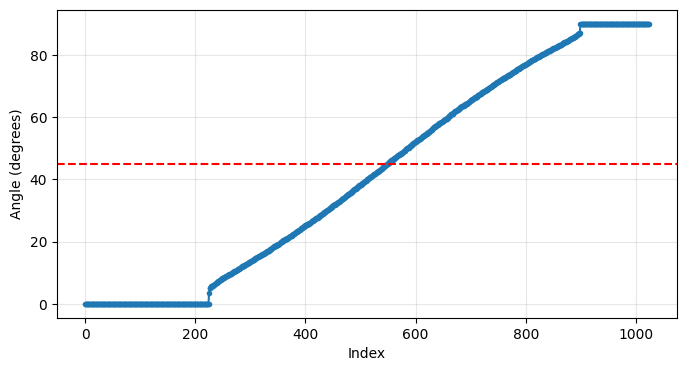

In [5]:
# per-column alignment angles of the sorted cosine factor (0° -> 90°)
plot_angles(g.C, target_deg=45);

## 3. Shared directions (rows of H)

The rows of `H` in the shared block are the directions jointly explained by
both classes. The one closest to 45° is the *principal shared component*;
directions near 0° are airplane-specific, near 90° ship-specific.

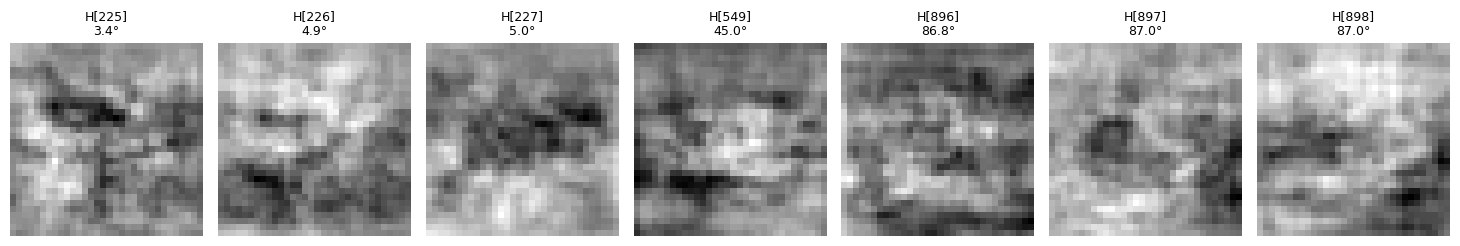

In [6]:
angles = get_angles_C(g.C)
psc = int(highlight_closest(angles, 45, 1)[0])
extremes_A = np.arange(g.bl, g.bl + 3)             # first shared (A side)
extremes_B = np.arange(g.bl + g.r - 3, g.bl + g.r) # last shared (B side)
picks = list(extremes_A) + [psc] + list(extremes_B)

fig, axes = plt.subplots(1, len(picks), figsize=(2.1 * len(picks), 2.5))
for ax, i in zip(axes, picks):
    render(ax, g.H[i, :], title=f"H[{i}]\n{angles[i]:.1f}\u00b0")
plt.tight_layout()

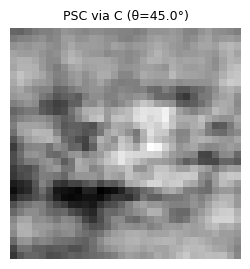

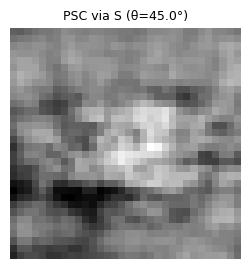

In [7]:
# reconstruction of the principal shared component on each side
plot_recon(g.C, g.H.T, psc, prep.mean_A, render,
           title=f"PSC via C (θ={angles[psc]:.1f}°)");
plot_recon(g.S, g.H.T, psc, prep.mean_B, render,
           title=f"PSC via S (θ={angles[psc]:.1f}°)");

## 4. Classification by the alignment angle θ(z)

For a test image `v`: solve `Hᵀc = v`, compute `θ = atan2(‖S c‖, ‖C c‖)`
restricted to col(A) ∩ col(B), and predict A iff θ < 45°.

In [8]:
angles_A, angles_B, acc = evaluate_pair(ds, LABEL_A, LABEL_B, prep,
                                        split="test", seed=4321)

=== Airplane ===  327/1000 correct (32.70%), mean θ = 45.55° (σ = 1.18°)
=== Ship ===  861/1000 correct (86.10%), mean θ = 46.17° (σ = 1.08°)
Overall accuracy: 59.40%


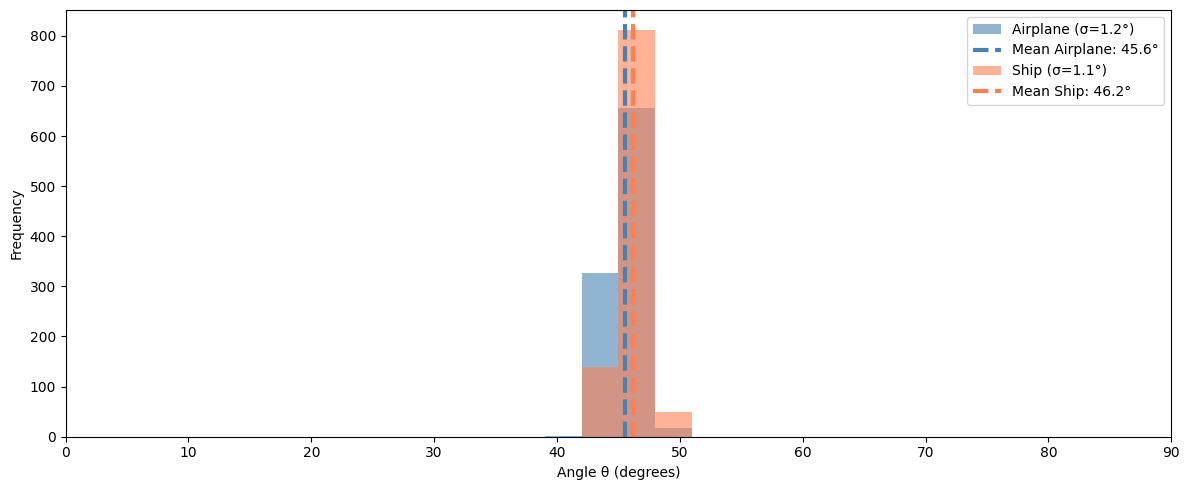

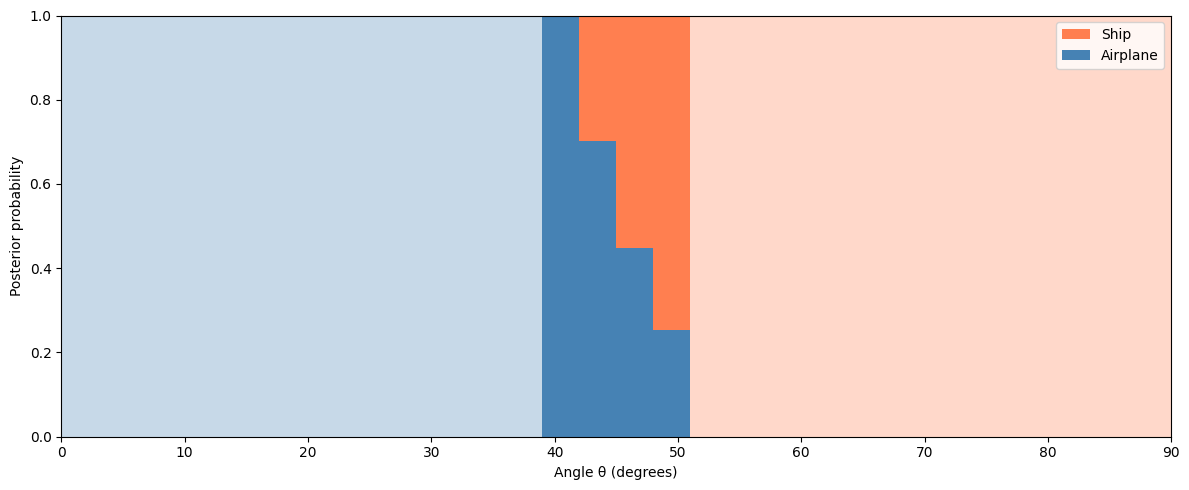

In [9]:
plot_angle_histogram(angles_A, angles_B,
                     ds.class_name(LABEL_A), ds.class_name(LABEL_B));
plot_posterior(angles_A, angles_B,
               ds.class_name(LABEL_A), ds.class_name(LABEL_B));

In [10]:
m = metrics_from_angles(angles_A, angles_B)
cka = linear_cka(prep.A, prep.B)
print(f"accuracy = {m['accuracy']:.4f}   linear CKA(A, B) = {cka:.4f}")
for side, lbl in (("A", LABEL_A), ("B", LABEL_B)):
    print(f"{ds.class_name(lbl):10s}  precision={m[f'precision_{side}']:.4f}"
          f"  recall={m[f'recall_{side}']:.4f}  f1={m[f'f1_{side}']:.4f}")

accuracy = 0.5940   linear CKA(A, B) = 0.9176
Airplane    precision=0.7017  recall=0.3270  f1=0.4461
Ship        precision=0.5613  recall=0.8610  f1=0.6796


## 5. A harder pair: Cat vs Dog

Same pipeline, one call. Expect much more overlap in θ (higher CKA, lower
accuracy) — the two classes share most of their geometry.

=== Cat ===  148/1000 correct (14.80%), mean θ = 46.05° (σ = 1.08°)
=== Dog ===  881/1000 correct (88.10%), mean θ = 46.26° (σ = 1.06°)
Overall accuracy: 51.45%
linear CKA(cat, dog) = 0.9817


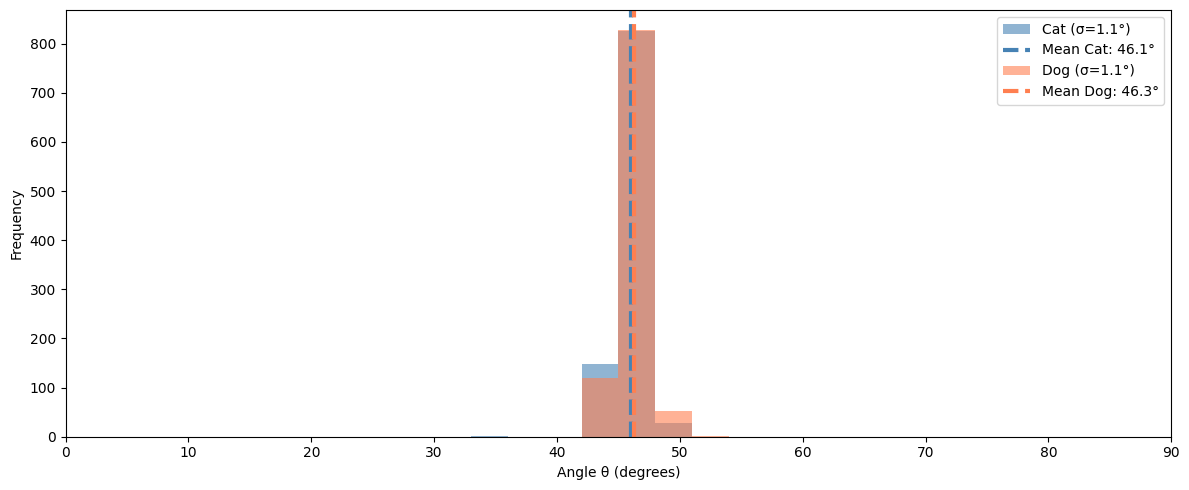

In [11]:
prep2 = prepare_data(ds, 3, 5, n_A=900, n_B=800, seed=1234)  # Cat, Dog
angles_cat, angles_dog, _ = evaluate_pair(ds, 3, 5, prep2,
                                          split="test", seed=4321)
plot_angle_histogram(angles_cat, angles_dog,
                     ds.class_name(3), ds.class_name(5));
print(f"linear CKA(cat, dog) = {linear_cka(prep2.A, prep2.B):.4f}")

## Interpretation

Unlike the MNIST pairs (CKA 0.11-0.74), CIFAR-10 grayscale pairs overlap
almost completely: CKA is 0.92 for Airplane vs Ship and 0.98 for Cat vs Dog,
and the shared block dominates (r = 674 of 1024 directions, with only
wl = wr = 1 exclusive "wires"). Consequently theta(z) concentrates in a
narrow band around 45-46 degrees and the fixed 45-degree threshold is poorly
calibrated for this geometry (59% / 51% balanced accuracy).

This is the paper's diagnostic working as intended: the angle distribution
*shows* that raw-pixel luminance geometry barely separates these classes -
most of what the two datasets span is shared structure (sky/water background,
low-frequency shapes). Two natural follow-ups: tune the decision threshold
(e.g. the midpoint of the two class means instead of 45), or apply the same
pipeline to learned features (embeddings) rather than raw pixels - which the
generic ArrayDataset supports directly.